In [31]:
import numpy as np
from pathlib import Path
from flopy.utils import HeadFile
from scipy.spatial import cKDTree

def get_centers_1d(mg, layer=None):
    # Para DIS/DISV: xcellcenters/ycellcenters pueden ser 2D; para DISU suelen ser 1D.
    x = np.asarray(mg.xcellcenters)
    y = np.asarray(mg.ycellcenters)
    return x.ravel(), y.ravel()

def load_heads(hds_path, kstpkper=None):
    hds = HeadFile(str(hds_path))
    if kstpkper is None:
        kstpkper = hds.get_kstpkper()[-1]
    h = hds.get_data(kstpkper=kstpkper)
    return np.asarray(h)

def interp_idw_to_points(xy_src, v_src, xy_tgt, k=3, eps=1e-12):
    """
    IDW usando k vecinos.
    xy_src: (Ns,2), v_src: (Ns,)
    xy_tgt: (Nt,2)
    """
    tree = cKDTree(xy_src)
    dist, idx = tree.query(xy_tgt, k=k)

    # Si k=1, dist y idx vienen 1D; lo normalizamos
    if k == 1:
        dist = dist[:, None]
        idx  = idx[:, None]

    # Pesos IDW
    w = 1.0 / np.maximum(dist, eps)
    v = v_src[idx]  # (Nt,k)
    v_idw = np.sum(w * v, axis=1) / np.sum(w, axis=1)
    return v_idw

# ---------- paths (ajusta a tus carpetas) ----------
ref_ws   = Path(r"C:\Users\sebas\Documents\AYUDANTE SNI\TESIS\yucatan_modelD\quadtreeGrid\gridgen_disu")   # carpeta del modelo quadtree (referencia) del mismo caso
other_ws = Path(r"C:\Users\sebas\Documents\AYUDANTE SNI\TESIS\yucatan_modelD\voronoiGrid")     # carpeta del modelo en otra malla (mismo caso)

ref_hds   = ref_ws / "quadtree_caseD.hds"
other_hds = other_ws / "voronoi_caseD.hds"

# ---------- cargar heads ----------
H_ref   = load_heads(ref_hds)     # shape: (nlay, ncpl?) o (nlay, nrow, ncol) según malla
H_other = load_heads(other_hds)

# ---------- cargar modelos / grids ----------
# Aquí asumo que ya tienes cargados los modelos (gwf_ref, gwf_other) en tu workflow.
# Si no, carga el sim con flopy.mf6.MFSimulation.load(...)

mg_ref   = gwf_ref.modelgrid
mg_other = gwf_other.modelgrid

# ---------- elegir capa a comparar (ej. capa 1 = layer 0) ----------
lay = 0

# heads 1D por celda
h_ref_lay = np.asarray(H_ref[lay]).ravel()
h_oth_lay = np.asarray(H_other[lay]).ravel()

# centros
x_ref, y_ref = get_centers_1d(mg_ref)
x_oth, y_oth = get_centers_1d(mg_other)

# máscara de activos (MUY importante)
id_ref = np.asarray(gwf_ref.dis.idomain.get_data()[lay]).ravel()
id_oth = np.asarray(gwf_other.dis.idomain.get_data()[lay]).ravel()

m_ref = (id_ref == 1) & np.isfinite(h_ref_lay)
m_oth = (id_oth == 1) & np.isfinite(h_oth_lay)

xy_ref = np.c_[x_ref[m_ref], y_ref[m_ref]]
xy_oth = np.c_[x_oth[m_oth], y_oth[m_oth]]

# interpolar other -> puntos ref
h_oth_on_ref = interp_idw_to_points(xy_oth, h_oth_lay[m_oth], xy_ref, k=3)

# diferencia
dh = h_oth_on_ref - h_ref_lay[m_ref]

# ahora dh está definido sobre los puntos activos de la ref (m_ref)
# Si quieres un array completo para plotear sobre quadtree:
dh_full = np.full(h_ref_lay.shape, np.nan)
dh_full[m_ref] = dh


TypeError: 'NoneType' object is not subscriptable

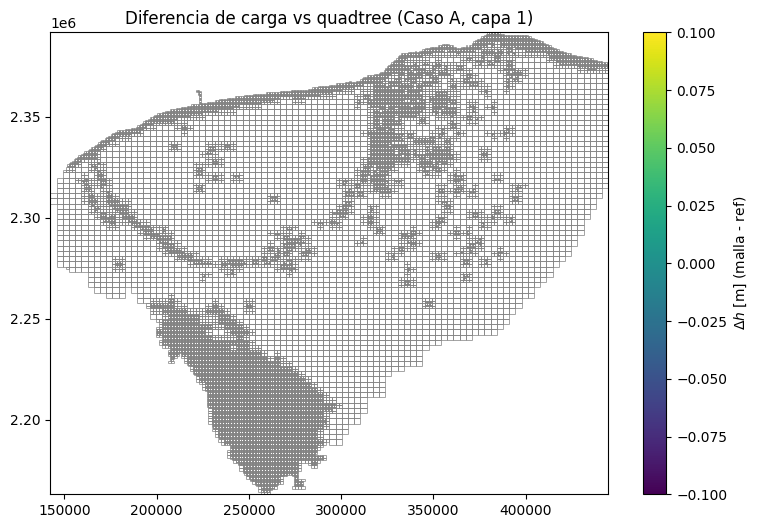

In [ ]:
import matplotlib.pyplot as plt
import flopy

fig, ax = plt.subplots(figsize=(9,6))
pmv = flopy.plot.PlotMapView(modelgrid=mg_ref, layer=lay, ax=ax)
im = pmv.plot_array(dh_full)  # Δh sobre la geometría ref
pmv.plot_grid(lw=0.5, alpha=1)
plt.colorbar(im, ax=ax, label=r"$\Delta h$ [m] (malla - ref)")
ax.set_title("Diferencia de carga vs quadtree (Caso A, capa 1)")
plt.show()
